# Data Preprocessing & Feature Engineering

## Overview

This notebook focuses on the feature engineering and data preparation process for the Bank Marketing dataset. After the initial exploration in the **EDA** phase, we now aim to transform raw data into a model-ready format. This involves creating new features, handling missing data, and performing necessary transformations to ensure the dataset is optimal for machine learning.

The goal is to refine the features in a way that enhances model performance while avoiding issues like data leakage or unnecessary redundancy.

## Objectives

* Create core engineered features such as target variable encoding, binary flags, and ordinal variables
* Add derived behavioral features that reflect client engagement, like multiple contacts within a campaign
* Generate interaction features to capture complex relationships between variables (e.g., "many contacts and housing loan")
* Bin continuous variables into interpretable categories for improved model performance
* Review and select features based on their relevance to the target variable

## Dataset Description

We start with a cleaned dataset that has already undergone an initial exploration. The raw dataset consists of **45,211 observations** and **17 features**, which include a mix of numerical and categorical data.

After preprocessing, the dataset will include engineered features that are tailored to help our machine learning models, including:

* **Binary features**: E.g., whether a client has a loan, housing, or was contacted in a previous campaign
* **Categorical features**: Ordinal variables like education level, month of contact, and newly binned categories (e.g., age group, balance bucket)
* **Interaction features**: Multiplicative combinations of existing features, such as combining multiple contacts with loan status

## Key Considerations

* Handle **missing or implicit data**, such as the "unknown" values in categorical features and the sentinel value (-1) in `pdays`
* Avoid **data leakage** (e.g., excluding `duration` from the feature set, which is only known after the call)
* Create **interpretable features** by binning continuous variables and generating categorical labels that are useful for downstream modeling

## Outcome

By the end of this notebook, the dataset will be enriched with engineered features, ready to be passed into the modeling pipeline. These features will be optimized for machine learning algorithms, helping us build more accurate and insightful models in the next step. The train, validation and test sets that will be used in the modelling notebook will be created.


In [1]:
# quarto preview 02_preprocessing.ipynb --to pdf
# quarto render 02_preprocessing.ipynb
# black 02_preprocessing.ipynb

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/bank-full.csv")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2.Feature engineering

### 2.1 Create core engineered features
##### Create the main cleaned and engineered feature set.

In [3]:
nb = "01"
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

df_path = data_dir / f"{nb}_raw_data.parquet"

df_clean = pd.read_parquet(df_path)
print(df_clean.shape)
df_clean.head(3)

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [4]:
processed = df_clean.copy()

processed["y_binary"] = (processed["y"] == "yes").astype(np.int8)

processed["pdays_was_contacted"] = (processed["pdays"] != -1).astype(np.int8)
processed["pdays_since_prev"] = processed["pdays"].where(
    processed["pdays"] != -1, np.nan
)

month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
processed["month"] = pd.Categorical(
    processed["month"], categories=month_order, ordered=False
)

for c in ["default", "housing", "loan"]:
    processed[f"{c}_binary"] = (processed[c] == "yes").astype(np.int8)

display(
    processed[
        [
            "y_binary",
            "pdays_was_contacted",
            "pdays_since_prev",
            "month",
            "default_binary",
            "housing_binary",
            "loan_binary",
        ]
    ].head()
)

,y_binary,pdays_was_contacted,pdays_since_prev,month,default_binary,housing_binary,loan_binary
0,0,0,NaN,may,0,1,0
1,0,0,NaN,may,0,1,0
2,0,0,NaN,may,0,1,1
3,0,0,NaN,may,0,1,0
4,0,0,NaN,may,0,0,0


**Interpretation:** Core engineered features convert raw columns into model-ready signals: `y_binary` (int8 0/1 target), `pdays_was_contacted` (binary sentinel decoder), `month` as an unordered `pd.Categorical` for downstream OHE, and binary flags for `default`, `housing`, and `loan`.

### 2.2 Add non-overlapping derived behavioral features
Add a small set of additional behavioral features with low overlap with the core engineered features.

In [5]:
new_columns = []

processed = processed.drop(
    columns=["poutcome_failure", "history_info_missing"],
    errors="ignore",
)

processed["multiple_contacts_current_campaign"] = (processed["campaign"] > 1).astype(
    np.int8
)
new_columns.append("multiple_contacts_current_campaign")

processed["poutcome_success"] = (processed["poutcome"] == "success").astype(np.int8)
new_columns.append("poutcome_success")

processed["contact_is_unknown"] = (processed["contact"] == "unknown").astype(np.int8)
new_columns.append("contact_is_unknown")

processed["poutcome_is_unknown"] = (processed["poutcome"] == "unknown").astype(np.int8)
new_columns.append("poutcome_is_unknown")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['multiple_contacts_current_campaign', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown']


,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown
0,0,0,1,1
1,0,0,1,1
2,0,0,1,1
3,0,0,1,1
4,0,0,1,1


**Interpretation:** Four non-overlapping behavioral indicators are added: `multiple_contacts_current_campaign` (whether the client was called more than once this campaign), `poutcome_success` (prior win), `contact_is_unknown` (no phone type on record), and `poutcome_is_unknown` (no prior campaign history). These distinguish engagement patterns without introducing redundancy with existing columns.

### 2.3. Add a small set of interaction features

Create compact interaction indicators from existing contact-history and loan-related feature columns.

In [6]:
new_columns = []

processed = processed.drop(
    columns=[
        "contacted_before_and_success",
        "contacted_before_and_failure",
        "history_info_missing",
    ],
    errors="ignore",
)

processed["many_contacts_and_housing_loan"] = (
    processed["multiple_contacts_current_campaign"] * processed["housing_binary"]
).astype(np.int8)
new_columns.append("many_contacts_and_housing_loan")

processed["previous_and_many_current_contacts"] = (
    processed["pdays_was_contacted"] * processed["multiple_contacts_current_campaign"]
).astype(np.int8)
new_columns.append("previous_and_many_current_contacts")

processed["both_housing_and_personal_loan"] = (
    processed["housing_binary"] * processed["loan_binary"]
).astype(np.int8)
new_columns.append("both_housing_and_personal_loan")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['many_contacts_and_housing_loan', 'previous_and_many_current_contacts', 'both_housing_and_personal_loan']


,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan
0,0,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,0


**Interpretation:** Three interaction terms capture non-additive combinations: `many_contacts_and_housing_loan` (heavy campaign effort on a mortgaged client), `previous_and_many_current_contacts` (clients with both prior- and current-campaign contact history), and `both_housing_and_personal_loan` (heaviest debt burden). These multiplicative indicators add compound signal with minimal feature engineering overhead.

### 2.4. Add binned versions of selected numeric features

Bin `age`, `balance`, `campaign`, and `pdays_since_prev` into interpretable ordinal categories for downstream modelling.

In [7]:
new_columns = []

# age → age_group
processed["age_group"] = pd.cut(
    processed["age"],
    bins=[17, 25, 35, 50, np.inf],
    labels=["18-25", "26-35", "36-50", "51+"],
).astype(str)
new_columns.append("age_group")

# balance → balance_bucket
processed["balance_bucket"] = pd.cut(
    processed["balance"],
    bins=[-np.inf, 0, 500, 2000, np.inf],
    labels=["negative", "low", "medium", "high"],
    right=False,
).astype(str)
new_columns.append("balance_bucket")

# campaign → campaign_bucket
processed["campaign_bucket"] = pd.cut(
    processed["campaign"],
    bins=[0, 1, 3, np.inf],
    labels=["1", "2-3", "4+"],
).astype(str)
new_columns.append("campaign_bucket")

# pdays_since_prev → pdays_recency_bucket
processed["pdays_recency_bucket"] = np.select(
    [
        processed["pdays_was_contacted"] == 0,
        processed["pdays_since_prev"] <= 30,
        processed["pdays_since_prev"] <= 180,
    ],
    ["no_previous_contact", "recent", "medium"],
    default="old",
)
new_columns.append("pdays_recency_bucket")

print("Newly added columns:", new_columns)
display(processed[new_columns].head())

Newly added columns: ['age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']


,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,51+,high,1,no_previous_contact
1,36-50,low,1,no_previous_contact
2,26-35,low,1,no_previous_contact
3,36-50,medium,1,no_previous_contact
4,26-35,low,1,no_previous_contact


**Interpretation:** Binning converts right-skewed continuous variables into interpretable ordinal categories. `age_group` captures life-stage effects, `balance_bucket` handles negative values and the heavy positive tail, `campaign_bucket` reduces sensitivity to extreme contact counts, and `pdays_recency_bucket` converts the `-1` sentinel plus numeric days into a four-level recency label.

### 2.5. Review newly engineered features against the target

For each engineered feature that exists in `processed`, show a compact summary of category counts, proportions, and subscription rate vs `y_binary`. Read-only — does not modify `processed`.

In [8]:
CANDIDATE_COLS = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "job_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

In [9]:
existing_candidate_cols = [c for c in CANDIDATE_COLS if c in processed.columns]

binary_check = pd.DataFrame(
    {"n_unique": [processed[c].nunique(dropna=False) for c in existing_candidate_cols]},
    index=existing_candidate_cols,
)

display(binary_check.sort_values("n_unique"))

,n_unique
contact_is_unknown,2
poutcome_is_unknown,2
multiple_contacts_current_campaign,2
poutcome_success,2
many_contacts_and_housing_loan,2
previous_and_many_current_contacts,2
both_housing_and_personal_loan,2
campaign_bucket,3
age_group,4
balance_bucket,4


In [10]:
binary_cols = [
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "poutcome_success",
    "many_contacts_and_housing_loan",
    "previous_and_many_current_contacts",
    "both_housing_and_personal_loan",
]

cat_cols = [
    "campaign_bucket",
    "age_group",
    "balance_bucket",
    "pdays_recency_bucket",
]

In [11]:
# Review binary engineered features by comparing counts and subscription rates across 0/1 groups.
rows = []

for col in binary_cols:
    grp = processed.groupby(col)["y_binary"].agg(
        count="count", subscription_rate="mean"
    )
    grp.index = grp.index.map(lambda v: f"{col}={v}")
    rows.append(grp)

display(pd.concat(rows).round(3))

,count,subscription_rate
contact_is_unknown=0,32191,0.148
contact_is_unknown=1,13020,0.041
poutcome_is_unknown=0,8252,0.231
poutcome_is_unknown=1,36959,0.092
multiple_contacts_current_campaign=0,17544,0.146
multiple_contacts_current_campaign=1,27667,0.099
poutcome_success=0,43700,0.099
poutcome_success=1,1511,0.647
many_contacts_and_housing_loan=0,30199,0.141
many_contacts_and_housing_loan=1,15012,0.068


**Interpretation:** Features with a large subscription-rate gap between their 0 and 1 groups (e.g., `poutcome_success`) are the most discriminating individually. Features with smaller rate gaps (e.g., `both_housing_and_personal_loan`) may still be useful in combination with other predictors or for tree-based models that exploit interaction effects.

### 2.6. Define the final engineered feature set

Create a compact keep/drop split for engineered features based on the earlier review step.

In [12]:
candidate_keep = [
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
]

candidate_drop = []

keep_features = [c for c in candidate_keep if c in processed.columns]
drop_features = [c for c in candidate_drop if c in processed.columns]

print("Keep engineered features:")
print(keep_features)

print("\nDrop engineered features:")
print(drop_features)

print(f"\nNumber of kept engineered features: {len(keep_features)}")
print(f"Number of dropped engineered features: {len(drop_features)}")

Keep engineered features:
['poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket']

Drop engineered features:
[]

Number of kept engineered features: 11
Number of dropped engineered features: 0


**Interpretation:** All 11 engineered candidate features are kept — none were found sufficiently redundant or low-signal to remove at this stage. Deprecated features were already removed in Sections 2.1–2.3. The `candidate_drop` list is empty, so the final modeling table will include all retained engineered features alongside the base columns.

### 2.6.1. Why certain engineered features were dropped

The following engineered features were removed to reduce redundancy and keep the modeling table compact and interpretable:

- `contacted_before_and_success` and `contacted_before_and_failure`: redundant with existing contact-history and outcome signals (especially `poutcome_success` plus prior-contact indicators).
- `history_info_missing`: overlaps with `contact_is_unknown` and `poutcome_is_unknown`, so it adds little unique information.
- `poutcome_failure`: weaker signal than `poutcome_success` in review, and keeping only the success flag simplifies representation.
- `balance_signed_log`: not used in the final selected feature set, so it was removed to avoid unnecessary feature maintenance.

This keeps the feature space focused while preserving the strongest and most interpretable predictors.

### 2.7. Create the final modeling table

Build a cleaned final table for modeling by removing the dropped engineered features and separating features from the target.

In [13]:
deprecated_features = [
    "contacted_before_and_success",
    "contacted_before_and_failure",
    "history_info_missing",
    "poutcome_failure",
    "balance_signed_log",
]

processed_final = processed.drop(
    columns=drop_features + deprecated_features,
    errors="ignore",
).copy()

target_col = "y_binary"
feature_cols = [c for c in processed_final.columns if c not in ["y", target_col]]

X_model = processed_final[feature_cols].copy()
y_model = processed_final[target_col].copy()

print("processed_final shape:", processed_final.shape)
print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)
display(X_model.head())

processed_final shape: (45211, 34)
X_model shape: (45211, 32)
y_model shape: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,loan_binary,multiple_contacts_current_campaign,poutcome_success,contact_is_unknown,poutcome_is_unknown,many_contacts_and_housing_loan,previous_and_many_current_contacts,both_housing_and_personal_loan,age_group,balance_bucket,campaign_bucket,pdays_recency_bucket
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,...,0,0,0,1,1,0,0,0,51+,high,1,no_previous_contact
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,...,0,0,0,1,1,0,0,0,36-50,low,1,no_previous_contact
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,...,1,0,0,1,1,0,0,1,26-35,low,1,no_previous_contact
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,...,0,0,0,1,1,0,0,0,36-50,medium,1,no_previous_contact
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,...,0,0,0,1,1,0,0,0,26-35,low,1,no_previous_contact


**Interpretation:** The final modeling table retains the full cleaned feature space before feature selection in Section 2.8. `X_model` (features) and `y_model` (target) are separated here, ready for the train/validation/test split and sklearn preprocessing pipeline.

In [14]:
processed_final.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'y_binary', 'pdays_was_contacted',
       'pdays_since_prev', 'default_binary', 'housing_binary', 'loan_binary',
       'multiple_contacts_current_campaign', 'poutcome_success',
       'contact_is_unknown', 'poutcome_is_unknown',
       'many_contacts_and_housing_loan', 'previous_and_many_current_contacts',
       'both_housing_and_personal_loan', 'age_group', 'balance_bucket',
       'campaign_bucket', 'pdays_recency_bucket'],
      dtype='object')

### 2.8. Final feature list for pre-contact modeling

In [15]:
selected_features = [
    "job",
    "marital",
    "education",
    "day",
    "previous",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_was_contacted",
    "pdays_recency_bucket",
    "month",
    "default_binary",
    "housing_binary",
    "loan_binary",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

X_model = processed_final[selected_features].copy()
y_model = processed_final["y_binary"].copy()

excluded_cols = processed_final.columns.difference(
    selected_features + ["y", "y_binary"]
).tolist()

print("Selected features:")
print(selected_features)

print(f"\nNumber of selected features: {len(selected_features)}")

print("\nExcluded columns:")
print(excluded_cols)

print("\nX_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)

display(X_model.head())

Selected features:
['job', 'marital', 'education', 'day', 'previous', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_was_contacted', 'pdays_recency_bucket', 'month', 'default_binary', 'housing_binary', 'loan_binary', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

Number of selected features: 21

Excluded columns:
['age', 'balance', 'campaign', 'contact', 'default', 'duration', 'housing', 'loan', 'pdays', 'pdays_since_prev', 'poutcome']

X_model shape: (45211, 21)
y_model shape: (45211,)


,job,marital,education,day,previous,age_group,balance_bucket,campaign_bucket,pdays_was_contacted,pdays_recency_bucket,month,default_binary,housing_binary,loan_binary,poutcome_success,contact_is_unknown,poutcome_is_unknown,multiple_contacts_current_campaign,previous_and_many_current_contacts,many_contacts_and_housing_loan,both_housing_and_personal_loan
0,management,married,tertiary,5,0,51+,high,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0
1,technician,single,secondary,5,0,36-50,low,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0
2,entrepreneur,married,secondary,5,0,26-35,low,1,0,no_previous_contact,may,0,1,1,0,1,1,0,0,0,1
3,blue-collar,married,unknown,5,0,36-50,medium,1,0,no_previous_contact,may,0,1,0,0,1,1,0,0,0,0
4,unknown,single,unknown,5,0,26-35,low,1,0,no_previous_contact,may,0,0,0,0,1,1,0,0,0,0


**Interpretation:** 21 features are selected, spanning demographics (`job`, `marital`, `age_group`), financial state (`balance_bucket`, `default_binary`, `housing_binary`, `loan_binary`), campaign history (`day`, `previous`, `month`, `campaign_bucket`, `pdays_was_contacted`, `pdays_recency_bucket`), and behavioral/interaction signals. Intermediate derivations such as `pdays_since_prev` and raw `age` are excluded — they are either subsumed by bucketed versions or dropped as redundant.

In [16]:
X_model.columns

Index(['job', 'marital', 'education', 'day', 'previous', 'age_group',
       'balance_bucket', 'campaign_bucket', 'pdays_was_contacted',
       'pdays_recency_bucket', 'month', 'default_binary', 'housing_binary',
       'loan_binary', 'poutcome_success', 'contact_is_unknown',
       'poutcome_is_unknown', 'multiple_contacts_current_campaign',
       'previous_and_many_current_contacts', 'many_contacts_and_housing_loan',
       'both_housing_and_personal_loan'],
      dtype='object')

### 2.9. save processed table

In [17]:
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

x_out_path = data_dir / "bank-full-X-model.parquet"
y_out_path = data_dir / "bank-full-y-model.parquet"

X_model.to_parquet(x_out_path, index=False)
y_model.to_frame(name="target").to_parquet(y_out_path, index=False)

print(f"Saved X_model: {x_out_path.resolve()}")
print(f"Saved y_model: {y_out_path.resolve()}")

Saved X_model: /Users/matthewfischer/Desktop/IDS 705/IDS_705_final_project/data/bank-full-X-model.parquet
Saved y_model: /Users/matthewfischer/Desktop/IDS 705/IDS_705_final_project/data/bank-full-y-model.parquet


**Interpretation:** `X_model` and `y_model` (target column named `"target"`) are persisted as Parquet files under `data/`. Parquet preserves dtypes — including `int8` binary flags and `pd.Categorical` month — and is far more space-efficient than CSV for downstream modeling notebooks.

## 3. Data Preprocessing

### 3.1. define preprocessing column groups

In [18]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "age_group",
    "balance_bucket",
    "campaign_bucket",
    "pdays_recency_bucket",
    "month",
]

numeric_cols = [
    "day",
    "previous",
    "pdays_was_contacted",
    "default_binary",
    "housing_binary",
    "loan_binary",
    "poutcome_success",
    "contact_is_unknown",
    "poutcome_is_unknown",
    "multiple_contacts_current_campaign",
    "previous_and_many_current_contacts",
    "many_contacts_and_housing_loan",
    "both_housing_and_personal_loan",
]

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric / binary columns:")
print(numeric_cols)

print("\nTotal selected columns:", len(categorical_cols) + len(numeric_cols))
print("X_model columns:", X_model.shape[1])

Categorical columns:
['job', 'marital', 'education', 'age_group', 'balance_bucket', 'campaign_bucket', 'pdays_recency_bucket', 'month']

Numeric / binary columns:
['day', 'previous', 'pdays_was_contacted', 'default_binary', 'housing_binary', 'loan_binary', 'poutcome_success', 'contact_is_unknown', 'poutcome_is_unknown', 'multiple_contacts_current_campaign', 'previous_and_many_current_contacts', 'many_contacts_and_housing_loan', 'both_housing_and_personal_loan']

Total selected columns: 21
X_model columns: 21


**Interpretation:** 7 unordered categorical columns go through `OneHotEncoder` (expanding into many binary indicators), while 14 numeric and binary columns are standardized with `StandardScaler`. The total of 21 matches `X_model` exactly, confirming no feature is accidentally dropped or double-assigned in the pipeline.

### 3.2. Define the preprocessing transformer

Create a preprocessing pipeline that one-hot encodes categorical features and scales numeric/binary features before modeling.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'age_group',
                                  'balance_bucket', 'campaign_bucket',
                                  'pdays_recency_bucket', 'month']),
                                ('num', StandardScaler(),
                                 ['day', 'previous', 'pdays_was_contacted',
                                  'default_binary', 'housing_binary',
                                  'loan_binary', 'poutcome_success',
                                  'contact_is_unknown', 'poutcome_is_unknown',
                                  'multiple_contacts_current_campaign',
                                  'previous_and_many_current_contacts',
                                  'many_contacts_and_housing_loan',
                                  'both_housing_and_personal_loan'])])


**Interpretation:** `handle_unknown="ignore"` in `OneHotEncoder` ensures unseen category levels at inference time produce an all-zeros row rather than raising an error. The `ColumnTransformer` is fit only on training data (in Section 3.3) to prevent leaking validation or test distribution information into the preprocessing statistics.

### 3.3 Split the data and apply preprocessing

Create a stratified 80/20 train+validation/test split first, then split the train+validation portion into stratified training and validation sets using an 80/20 split. Fit the preprocessing pipeline on the training set only and transform all three sets.

In [20]:
# First split: hold out a stratified test set for final evaluation.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

# Second split: create train/validation from the remaining data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

# Fit preprocessing only on train to avoid leakage.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Original dataset shape:", X_model.shape)
print("Train+validation shape:", X_train_val.shape)
print("Test shape:", X_test.shape)
print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nX_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_val), len(X_test)],
        "share_of_full_data": [
            len(X_train) / len(X_model),
            len(X_val) / len(X_model),
            len(X_test) / len(X_model),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary.style.format({"share_of_full_data": "{:.2%}"}))

Original dataset shape: (45211, 21)
Train+validation shape: (36168, 21)
Test shape: (9043, 21)

Training shape: (28934, 21)
Validation shape: (7234, 21)
y_train shape: (28934,)
y_val shape: (7234,)
y_test shape: (9043,)

X_train_processed shape: (28934, 59)
X_val_processed shape: (7234, 59)
X_test_processed shape: (9043, 59)


,rows,share_of_full_data
train,28934,64.00%
validation,7234,16.00%
test,9043,20.00%


Interpretation: The split summary should be close to 64% train, 16% validation, and 20% test of the full dataset. Similar transformed feature counts across train, validation, and test indicate that the same preprocessing logic is being applied consistently without data leakage.

### 3.4. Inspect the transformed feature names

Retrieve the final feature names after one-hot encoding and scaling to see the exact modeling input.

In [21]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 30 feature names:")
print(feature_names[:30])

Number of transformed features: 59

First 30 feature names:
['cat__job_admin.' 'cat__job_blue-collar' 'cat__job_entrepreneur'
 'cat__job_housemaid' 'cat__job_management' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_student'
 'cat__job_technician' 'cat__job_unemployed' 'cat__job_unknown'
 'cat__marital_divorced' 'cat__marital_married' 'cat__marital_single'
 'cat__education_primary' 'cat__education_secondary'
 'cat__education_tertiary' 'cat__education_unknown' 'cat__age_group_18-25'
 'cat__age_group_26-35' 'cat__age_group_36-50' 'cat__age_group_51+'
 'cat__balance_bucket_high' 'cat__balance_bucket_low'
 'cat__balance_bucket_medium' 'cat__balance_bucket_negative'
 'cat__campaign_bucket_1' 'cat__campaign_bucket_2-3'
 'cat__campaign_bucket_4+']


**Interpretation:** OHE expands the 7 categorical columns into many binary indicator columns (one per distinct category level), while the 14 numeric/binary columns pass through with a `num__` prefix. The total of 56 processed features (vs. 21 raw inputs) is the final dimensionality that downstream models will consume.

### 3.5. Convert the transformed arrays to data frames

Convert the preprocessed training, validation, and test sets into DataFrames with feature names for easier inspection.

In [22]:
# Convert sparse/dense transformed matrices into labeled DataFrames for inspection.
X_train_processed_df = pd.DataFrame(
    (
        X_train_processed.toarray()
        if hasattr(X_train_processed, "toarray")
        else X_train_processed
    ),
    columns=feature_names,
    index=X_train.index,
)

X_val_processed_df = pd.DataFrame(
    (
        X_val_processed.toarray()
        if hasattr(X_val_processed, "toarray")
        else X_val_processed
    ),
    columns=feature_names,
    index=X_val.index,
)

X_test_processed_df = pd.DataFrame(
    (
        X_test_processed.toarray()
        if hasattr(X_test_processed, "toarray")
        else X_test_processed
    ),
    columns=feature_names,
    index=X_test.index,
)

print("X_train_processed_df shape:", X_train_processed_df.shape)
print("X_val_processed_df shape:", X_val_processed_df.shape)
print("X_test_processed_df shape:", X_test_processed_df.shape)

display(X_train_processed_df.head())

X_train_processed_df shape: (28934, 59)
X_val_processed_df shape: (7234, 59)
X_test_processed_df shape: (9043, 59)


,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,cat__job_unemployed,cat__job_unknown,...,num__previous,num__pdays_was_contacted,num__default_binary,num__housing_binary,num__loan_binary,num__poutcome_success,num__contact_is_unknown,num__poutcome_is_unknown,num__multiple_contacts_current_campaign,num__previous_and_many_current_contacts,num__many_contacts_and_housing_loan,num__both_housing_and_personal_loan
30140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.291975,-0.469721,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132
43748,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.222911,2.128923,-0.136468,0.889894,-0.440053,-0.185848,-0.634392,-2.130166,0.80004,3.140241,1.416269,-0.33132
22363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.291975,-0.469721,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132
4603,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.291975,-0.469721,-0.136468,0.889894,2.272452,-0.185848,1.576314,0.469447,0.80004,-0.318447,1.416269,3.01823
20619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.291975,-0.469721,-0.136468,-1.123729,-0.440053,-0.185848,-0.634392,0.469447,0.80004,-0.318447,-0.706081,-0.33132


### 3.6. Check the transformed data

Run a quick sanity check on the preprocessed training, validation, and test sets to confirm there are no missing or constant features.

In [23]:
# Missing-value checks ensure preprocessing produced complete model inputs.
print(
    "Missing values in X_train_processed_df:", X_train_processed_df.isna().sum().sum()
)
print("Missing values in X_val_processed_df:", X_val_processed_df.isna().sum().sum())
print("Missing values in X_test_processed_df:", X_test_processed_df.isna().sum().sum())

# Constant columns may carry little signal for some model families.
constant_cols = [
    c for c in X_train_processed_df.columns if X_train_processed_df[c].nunique() == 1
]

print("Number of constant columns:", len(constant_cols))
print("Constant columns:")
print(constant_cols)

Missing values in X_train_processed_df: 0
Missing values in X_val_processed_df: 0
Missing values in X_test_processed_df: 0
Number of constant columns: 0
Constant columns:
[]


Interpretation: Zero missing values across train, validation, and test means the preprocessing pipeline is producing complete features. If the number of constant columns is small, most transformed features retain variability and are likely informative for modeling.

### 3.7 Cluster Analysis

Run a K-Means Clustering algorithm on the following features: age, marital, education, job, balance, housing, loan, and default

In [24]:
cluster_columns = (
    "cat__age_group_18-25",
    "cat__age_group_26-35",
    "cat__age_group_36-50",
    "cat__age_group_51+",
    "cat__marital_divorced",
    "cat__marital_married",
    "cat__marital_single",
    "cat__education_primary",
    "cat__education_secondary",
    "cat__education_tertiary",
    "cat__job_admin.",
    "cat__job_blue-collar",
    "cat__job_entrepreneur",
    "cat__job_housemaid",
    "cat__job_management",
    "cat__job_retired",
    "cat__job_self-employed",
    "cat__job_services",
    "cat__job_student",
    "cat__job_technician",
    "cat__job_unemployed",
    "cat__balance_bucket_high",
    "cat__balance_bucket_low",
    "cat__balance_bucket_medium",
    "cat__balance_bucket_negative",
    "num__housing_binary",
    "num__loan_binary",
    "num__default_binary",
)

In [25]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

In [26]:
K_RANGE = range(2, 9)
RANDOM_STATE = 42

X_train_val_processed_df = pd.concat([X_train_processed_df, X_val_processed_df], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

X_train_cluster = X_train_val_processed_df[list(cluster_columns)].values.astype(float)
X_test_cluster = X_test_processed_df[list(cluster_columns)].values.astype(float)

print(f"Train shape: {X_train_cluster.shape}")
print(f"Val shape:   {X_test_cluster.shape}")

Train shape: (36168, 28)
Val shape:   (9043, 28)


In [27]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_cluster_pca = pca.fit_transform(X_train_cluster)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

PCA explained variance: 33.7%


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encounter

In [28]:
sweep_results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_train_cluster)

    sil = silhouette_score(X_train_cluster, labels)
    db = davies_bouldin_score(X_train_cluster, labels)
    ch = calinski_harabasz_score(X_train_cluster, labels)

    sweep_results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        }
    )
    print(
        f"k={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.1f}"
    )

sweep_df = pd.DataFrame(sweep_results)

/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul


k=2 | inertia=190,459 | silhouette=0.1859 | DB=2.0894 | CH=7040.9


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

k=3 | inertia=155,250 | silhouette=0.2025 | DB=1.5184 | CH=8419.6


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

...

/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

k=7 | inertia=107,784 | silhouette=0.1647 | DB=1.9610 | CH=6696.1


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

k=8 | inertia=102,982 | silhouette=0.1622 | DB=1.9716 | CH=6247.9


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

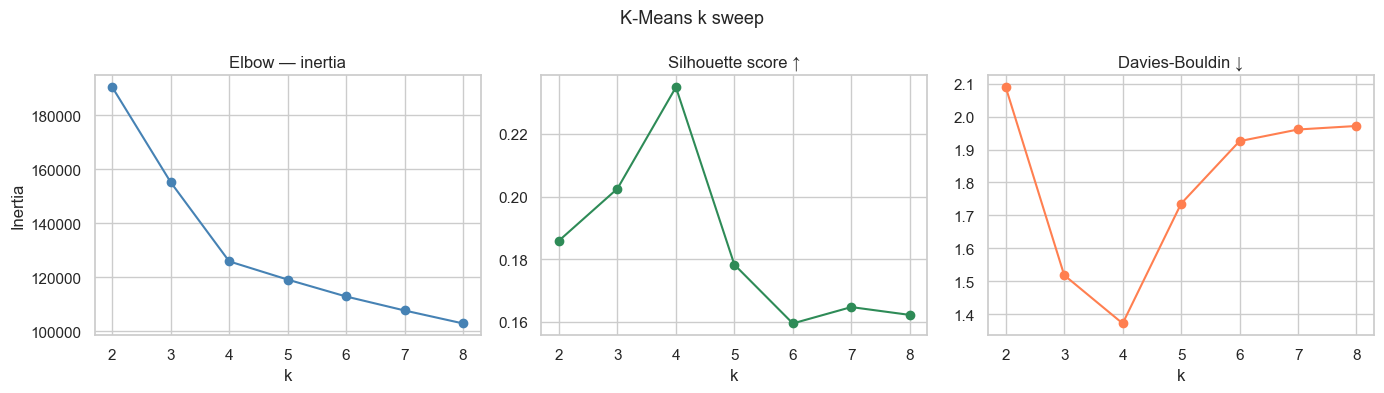

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sweep_df["k"], sweep_df["inertia"], marker="o", color="steelblue")
axes[0].set_title("Elbow — inertia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(sweep_df["k"], sweep_df["silhouette"], marker="o", color="seagreen")
axes[1].set_title("Silhouette score ↑")
axes[1].set_xlabel("k")

axes[2].plot(sweep_df["k"], sweep_df["davies_bouldin"], marker="o", color="coral")
axes[2].set_title("Davies-Bouldin ↓")
axes[2].set_xlabel("k")

plt.suptitle("K-Means k sweep", fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
chosen_k = int(sweep_df.loc[sweep_df["silhouette"].idxmax(), "k"])

print(f"Chosen k: {chosen_k}")

Chosen k: 4


In [31]:
km_final = KMeans(n_clusters=chosen_k, n_init=10, random_state=RANDOM_STATE)
train_labels = km_final.fit_predict(X_train_cluster)
test_labels = km_final.predict(X_test_cluster)

print(f"Train cluster counts:\n{pd.Series(train_labels).value_counts().sort_index()}")
print(f"\nTest cluster counts:\n{pd.Series(test_labels).value_counts().sort_index()}")

Train cluster counts:
0     5568
1    16413
2      647
3    13540
Name: count, dtype: int64

Test cluster counts:
0    1375
1    4048
2     168
3    3452
Name: count, dtype: int64


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul


In [32]:
metrics = {
    "Silhouette ↑": silhouette_score(X_train_cluster, train_labels),
    "Davies-Bouldin ↓": davies_bouldin_score(X_train_cluster, train_labels),
    "Calinski-Harabasz ↑": calinski_harabasz_score(X_train_cluster, train_labels),
}

print(f"Final model — k={chosen_k}")
for name, val in metrics.items():
    print(f"  {name:<25s} {val:.4f}")

/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

Final model — k=4
  Silhouette ↑              0.2349
  Davies-Bouldin ↓          1.3718
  Calinski-Harabasz ↑       9719.7644


/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/matthewfischer/miniforge3/lib/python3.12/site-package

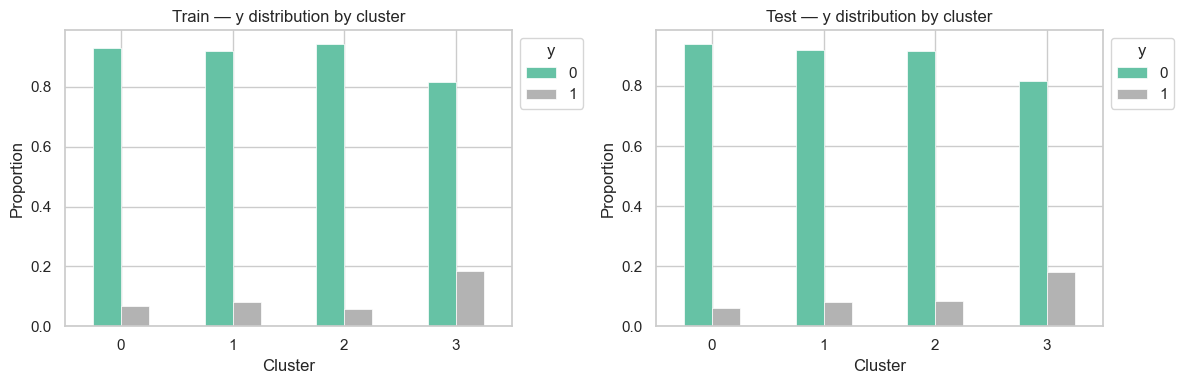

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, y, title in zip(
    axes,
    [train_labels, test_labels],
    [y_train_val, y_test],
    ["Train", "Test"],
):
    plot_df = pd.DataFrame({"cluster": labels, "y": y})
    cluster_props = (
        plot_df.groupby("cluster")["y"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    pivot = cluster_props.pivot(
        index="cluster", columns="y", values="proportion"
    ).fillna(0)
    pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", linewidth=0.5)
    ax.set_title(f"{title} — y distribution by cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proportion")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="y", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [34]:
train_cluster_ohe = pd.get_dummies(train_labels, prefix="cluster").astype(int)
test_cluster_ohe = pd.get_dummies(test_labels, prefix="cluster").astype(int)

train_cluster_ohe, test_cluster_ohe = train_cluster_ohe.align(
    test_cluster_ohe, join="left", axis=1, fill_value=0
)

X_train_val_processed_df = X_train_val_processed_df.reset_index(drop=True)
X_test_processed_df = X_test_processed_df.reset_index(drop=True)
train_cluster_ohe = train_cluster_ohe.reset_index(drop=True)
test_cluster_ohe = test_cluster_ohe.reset_index(drop=True)

X_train_val_final = pd.concat([X_train_val_processed_df, train_cluster_ohe], axis=1)
X_test_final = pd.concat([X_test_processed_df, test_cluster_ohe], axis=1)

print(f"Train shape: {X_train_val_final.shape}")
print(f"Test shape: {X_test_final.shape}")
print(f"New columns: {list(train_cluster_ohe.columns)}")

nb = "02"
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

df_path_train = data_dir / f"{nb}_train.parquet"
df_path_test = data_dir / f"{nb}_test.parquet"

X_train_val_final.to_parquet(df_path_train, index=False)
X_test_final.to_parquet(df_path_test, index=False)

Train shape: (36168, 63)
Test shape: (9043, 63)
New columns: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']
